# Exploratory Data Analysis & Descriptive Statistics on Titanic Dataset
### A Complete End-to-End Practical Implementation with Python & Seaborn
This notebook covers descriptive statistics, distributions, five-number summary, IQR, boxplots, covariance, correlation, 3D scatter plots, multivariable visualizations (Hue, FacetGrid, Jointplot, Pairplot, Bubble Plot), and categorical survival analysis using the Question → Visualization/Code → Observation methodology.


## Environment Setup & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Configure aesthetic styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8, 5)

# Load Seaborn's standard Titanic dataset
df = sns.load_dataset('titanic')
print("Dataset loaded successfully! Initial shape:", df.shape)
df.head()


Dataset loaded successfully! Initial shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## SECTION A — Basic Data Understanding & Missing Values

### Q1. Titanic dataset mein kitne passengers aur kitne features hain?
* **Objective**: Dataset dimensions, column datatypes, and null value count ka inspection.


In [2]:
# Q1: Basic shape and information
print(f"Total Rows (Passengers): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")
print("Data Types and Non-Null Counts:")
df.info()


Total Rows (Passengers): 891
Total Columns (Features): 15

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


**Observation for Q1:**
* Dataset me 891 passengers (rows) aur 15 variables (columns) hain.
* Numerical variables: `age`, `fare`, `sibsp`, `parch`, `survived`, `pclass`.
* Categorical/Text variables: `sex`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`.


### Q2. Dataset mein missing values kahan-kahan hain?
* **Question**: Which variables contain missing observations and which has the highest missing count?
* **Visualization**: Missing values bar chart.


Missing values summary:
deck           688
age            177
embarked         2
embark_town      2
dtype: int64


C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\334576078.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette='mako')


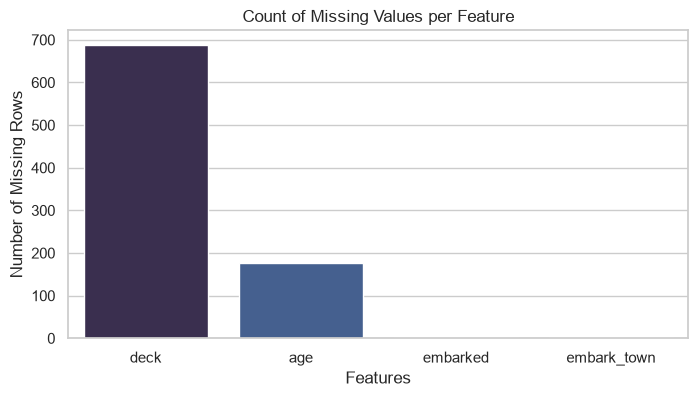

In [3]:
# Q2: Missing value distribution
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values summary:")
print(missing)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, palette='mako')
plt.title("Count of Missing Values per Feature")
plt.ylabel("Number of Missing Rows")
plt.xlabel("Features")
plt.show()


**Observation for Q2:**
* `deck` variable me sabse zyada missing values hain (688 out of 891 ~ 77.2%).
* `age` column me 177 missing values hain (~19.9%).
* `embarked` aur `embark_town` dono me sirf 2 missing rows hain.


---
## SECTION B — Quantiles & Percentiles

### Q3. Titanic passengers ki age distribution mein Q1, median aur Q3 kya hain?
* **Visualization**: Age Boxplot highlighting quartiles and outliers.


Age Quantiles:
0.25    20.125
0.50    28.000
0.75    38.000
Name: age, dtype: float64


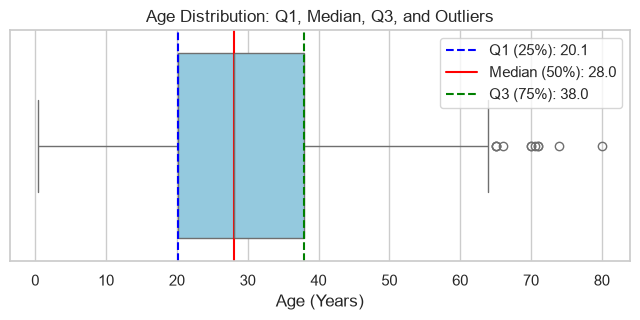

In [4]:
# Q3: Age Quantiles & Boxplot
age_quantiles = df['age'].dropna().quantile([0.25, 0.50, 0.75])
print("Age Quantiles:")
print(age_quantiles)

plt.figure(figsize=(8, 3))
sns.boxplot(x=df['age'], color='skyblue')
plt.axvline(age_quantiles[0.25], color='blue', linestyle='--', label=f'Q1 (25%): {age_quantiles[0.25]:.1f}')
plt.axvline(age_quantiles[0.50], color='red', linestyle='-', label=f'Median (50%): {age_quantiles[0.50]:.1f}')
plt.axvline(age_quantiles[0.75], color='green', linestyle='--', label=f'Q3 (75%): {age_quantiles[0.75]:.1f}')
plt.title("Age Distribution: Q1, Median, Q3, and Outliers")
plt.xlabel("Age (Years)")
plt.legend()
plt.show()


**Observation for Q3:**
* **Q1 (25th percentile)** = 20.12 saal (25% log lagbhag 20 saal se chhote the).
* **Median (50th percentile)** = 28.00 saal.
* **Q3 (75th percentile)** = 38.00 saal (75% log 38 saal ya usse kam umar ke the).
* Right whisker ke paar (~65+ saal) outliers maujood hain.


### Q4. Titanic passengers ke fares ka 25th, 50th aur 75th percentile kya hai?
* **Visualization**: Fare Boxplot highlighting extreme positive skewness.


Fare Percentiles:
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: fare, dtype: float64


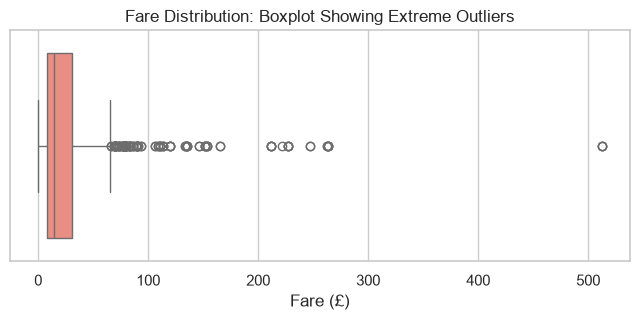

In [5]:
# Q4: Fare Percentiles & Boxplot
fare_quantiles = df['fare'].quantile([0.25, 0.50, 0.75])
print("Fare Percentiles:")
print(fare_quantiles)

plt.figure(figsize=(8, 3))
sns.boxplot(x=df['fare'], color='salmon')
plt.title("Fare Distribution: Boxplot Showing Extreme Outliers")
plt.xlabel("Fare (£)")
plt.show()


**Observation for Q4:**
* **25th Percentile (Q1)** = £7.91
* **50th Percentile (Median)** = £14.45
* **75th Percentile (Q3)** = £31.00
* Median fare bohot low (£14.45) hai jabki maximum fare £512.33 tak ja raha hai. Fare me severe positive (right) skewness aur multiple extreme outliers hain.


---
## SECTION C & D — Five Number Summary & Interquartile Range (IQR)

### Q5. Titanic passengers ke age aur fare ka Five-Number Summary kya hai?
* **Minimum → Q1 → Median → Q3 → Maximum**


In [6]:
# Q5: Five-number summary calculation
five_num = pd.DataFrame({
    'Min': [df['age'].min(), df['fare'].min()],
    'Q1 (25%)': [df['age'].quantile(0.25), df['fare'].quantile(0.25)],
    'Median': [df['age'].median(), df['fare'].median()],
    'Q3 (75%)': [df['age'].quantile(0.75), df['fare'].quantile(0.75)],
    'Max': [df['age'].max(), df['fare'].max()]
}, index=['Age', 'Fare'])

print("Five-Number Summary Table:")
display(five_num.round(2))


Five-Number Summary Table:


,Min,Q1 (25%),Median,Q3 (75%),Max
Age,0.42,20.12,28.00,38.0,80.00
Fare,0.00,7.91,14.45,31.0,512.33


**Observation for Q5:**
* Age ka minimum 0.42 saal (infant) se maximum 80 saal tak hai.
* Fare ka minimum £0 (free ticket/crew passes) se maximum £512.33 tak hai.


### Q6. Titanic passengers ke age aur fare ka IQR kya hai?
* **Question**: Which variable has greater variability relative to its scale: Age or Fare?
* $\text{IQR} = Q3 - Q1$


In [7]:
# Q6: Interquartile Range
iqr_age = df['age'].quantile(0.75) - df['age'].quantile(0.25)
iqr_fare = df['fare'].quantile(0.75) - df['fare'].quantile(0.25)

print(f"Age IQR : {iqr_age:.2f} years")
print(f"Fare IQR: £{iqr_fare:.2f}")

# Relative IQR (IQR / Median)
print(f"Relative IQR for Age : {iqr_age / df['age'].median():.2f}")
print(f"Relative IQR for Fare: {iqr_fare / df['fare'].median():.2f}")


Age IQR : 17.88 years
Fare IQR: £23.09
Relative IQR for Age : 0.64
Relative IQR for Fare: 1.60


**Observation for Q6:**
* **Age IQR** = 17.88 years (middle 50% passengers lagbhag 18 saal ke span me the).
* **Fare IQR** = £23.09.
* Relative dispersion dekhne par Fare ka IQR uske median se 1.6 times zyada hai, jabki Age ka IQR median ka 0.63 times hai. Iska matlab Fare me relative variability Age se kaafi zyada hai.


---
## SECTION E — Boxplot Analysis

### Q7. Male aur female passengers ki age distribution mein kya difference hai?
* **Visualization**: Side-by-side boxplot by gender.


C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\3666105200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='age', palette='Set2')


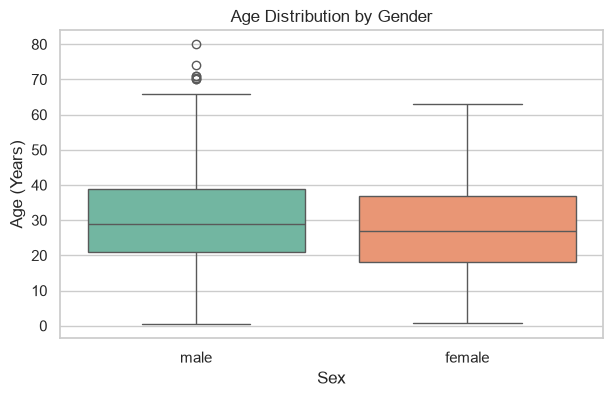

In [8]:
# Q7: Age by Gender
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='sex', y='age', palette='Set2')
plt.title("Age Distribution by Gender")
plt.xlabel("Sex")
plt.ylabel("Age (Years)")
plt.show()


**Observation for Q7:**
* Male passengers ki median age (~29) females (~27) se slightly zyada thi.
* Males me elderly outliers (~65 to 80 years) females ke muqable zyada hain.


### Q8. Passenger class ke according fare distribution kya hai?
* **Visualization**: Side-by-side boxplot (with log scale for readability).


C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\3499177576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='fare', palette='Set1')


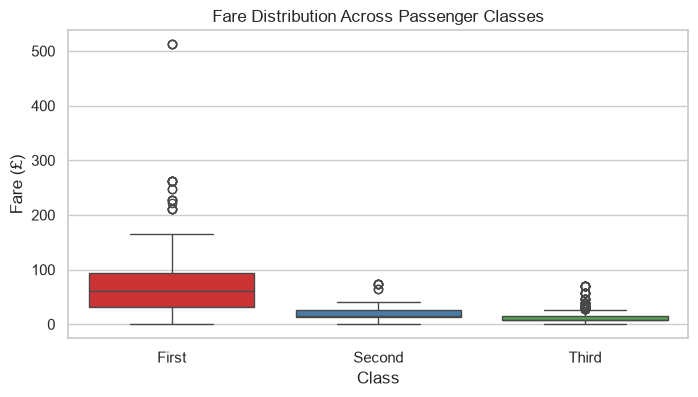

C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\3499177576.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y='fare', palette='Set1')


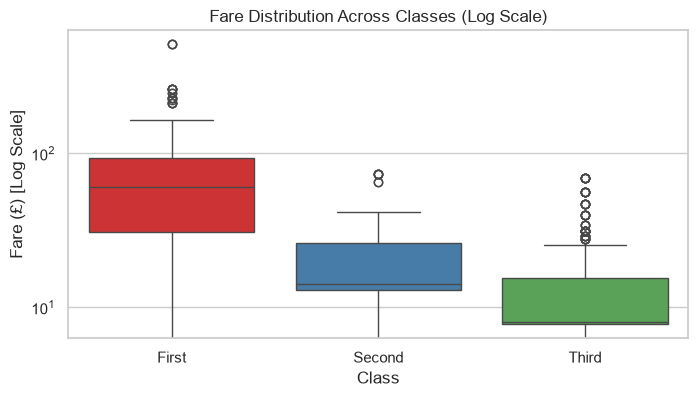

In [9]:
# Q8: Fare by Class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='class', y='fare', palette='Set1')
plt.title("Fare Distribution Across Passenger Classes")
plt.xlabel("Class")
plt.ylabel("Fare (£)")
plt.show()

# Optional: Log scale representation
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='class', y='fare', palette='Set1')
plt.yscale('log')
plt.title("Fare Distribution Across Classes (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Fare (£) [Log Scale]")
plt.show()


**Observation for Q8:**
* First class fares significantly higher hain (median ~£60) compared to Second (£14.25) aur Third (£8.05).
* Third class me tickets bohot cheap aur tightly clustered thin, jabki First class me huge variance aur extreme luxury outliers maujood the.


### Q9. Survival status ke according age distribution kya hai?
* **Visualization**: Side-by-side boxplot across Survival status.


C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\2017950279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='survived', y='age', palette='coolwarm')


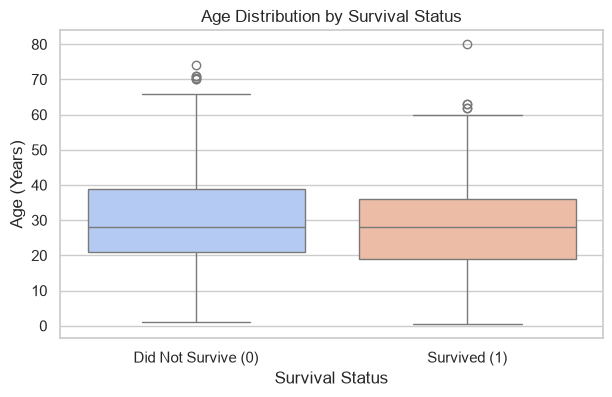

In [10]:
# Q9: Age by Survival Status
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='survived', y='age', palette='coolwarm')
plt.title("Age Distribution by Survival Status")
plt.xticks([0, 1], ['Did Not Survive (0)', 'Survived (1)'])
plt.xlabel("Survival Status")
plt.ylabel("Age (Years)")
plt.show()


**Observation for Q9:**
* Dono groups ka median age almost identical (~28 years) hai.
* Halanki, survived group me young children aur infants ka spread zyada noticeable hai, jabki non-survived group me upper age outliers zyada hain.


---
## SECTION F, G, H, I & J — Scatterplots, Covariance & Correlation

### Q10. Age aur Fare ke beech relationship kya hai?
* **Visualization**: Scatterplot of Age vs Fare.


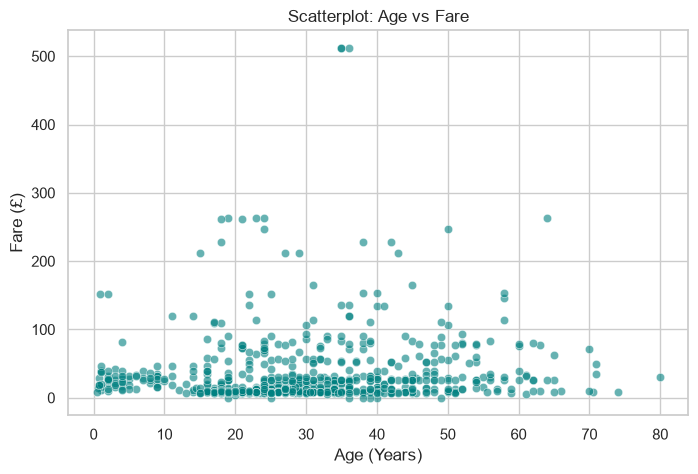

In [11]:
# Q10: Age vs Fare Scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='fare', alpha=0.6, color='teal')
plt.title("Scatterplot: Age vs Fare")
plt.xlabel("Age (Years)")
plt.ylabel("Fare (£)")
plt.show()


**Observation for Q10:**
* Points lower fare area me clustered hain regardless of age.
* Koi clear linear relationship visible nahi hai; extreme high fares mainly 30 se 60 saal ke age group me pay kiye gaye the.


### Q11 & Q12. Titanic dataset mein Covariance kya hai?
* **Definition**: Covariance batata hai do variables same direction ($+$) me move karte hain ya opposite ($-$). Scale-dependent hota hai.


Sample Covariance between Age and Fare: 73.85

Covariance Matrix:


,survived,age,sibsp,parch,fare
survived,0.24,-0.55,-0.02,0.03,6.22
age,-0.55,211.02,-4.16,-2.34,73.85
sibsp,-0.02,-4.16,1.22,0.37,8.75
parch,0.03,-2.34,0.37,0.65,8.66
fare,6.22,73.85,8.75,8.66,2469.44


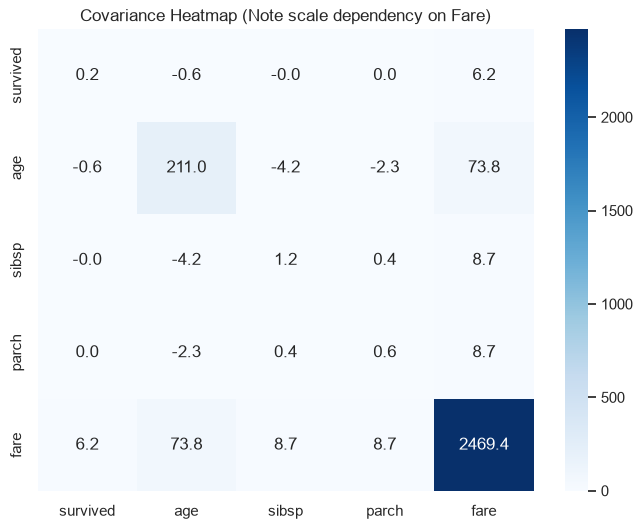

In [12]:
# Q11 & Q12: Covariance calculation & Covariance Matrix
num_cols = ['survived', 'age', 'sibsp', 'parch', 'fare']
cov_matrix = df[num_cols].cov()

print(f"Sample Covariance between Age and Fare: {cov_matrix.loc['age', 'fare']:.2f}\n")
print("Covariance Matrix:")
display(cov_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt='.1f', cmap='Blues')
plt.title("Covariance Heatmap (Note scale dependency on Fare)")
plt.show()


**Observation for Q11 & Q12:**
* `Cov(Age, Fare) ≈ 73.84` (positive direction: umar badhne ke sath fare thoda badhta hai).
* **Limitation of Covariance**: `Var(Fare)` 2469.4 hai kyunki fare pounds me measure hota hai. Is scale explosion ki wajah se hum relationships ki strength ko directly compare nahi kar sakte.


### Q13. Titanic ke numerical variables ke beech Correlation kya hai?
* **Definition**: Standardized linear association $[-1, +1]$.


Correlation Matrix:


,survived,age,sibsp,parch,fare
survived,1.000,-0.077,-0.035,0.082,0.257
age,-0.077,1.000,-0.308,-0.189,0.096
sibsp,-0.035,-0.308,1.000,0.415,0.160
parch,0.082,-0.189,0.415,1.000,0.216
fare,0.257,0.096,0.160,0.216,1.000


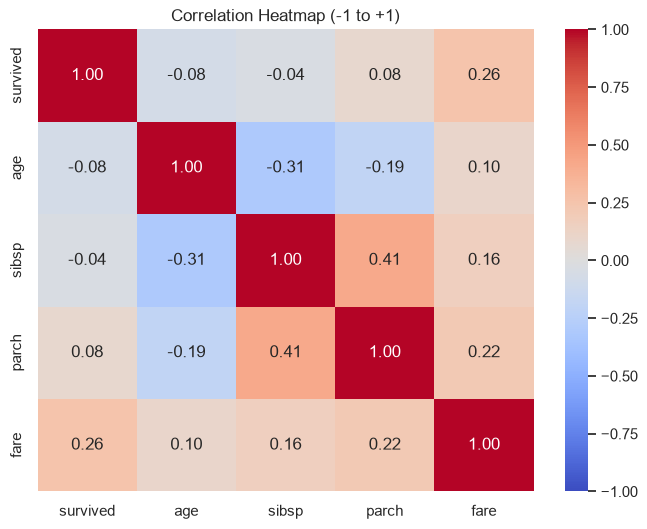

In [13]:
# Q13: Correlation Heatmap
corr_matrix = df[num_cols].corr()

print("Correlation Matrix:")
display(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap (-1 to +1)")
plt.show()


**Observation for Q13:**
* `fare` aur `survived` ke beech positive correlation hai ($r = +0.26$), jo dikhata hai higher fare dene walon ke survival chance thode zyada the.
* `age` aur `survived` me weak negative correlation hai ($r = -0.08$).
* `sibsp` aur `parch` me moderate positive correlation hai ($r = +0.41$) kyunki family members sath travel karte the.


### Q14. Covariance vs Correlation Summary

| Feature | Covariance | Correlation |
| :--- | :--- | :--- |
| **Kya batata hai?** | Sirf relationship ka direction | Direction + Standardized Strength |
| **Range** | $-\infty$ to $+\infty$ | $-1.0$ to $+1.0$ |
| **Units** | Variable units ka product ($Years \times \text{Pounds}$) | Unitless |
| **Comparison** | Variables across compare nahi kar sakte | Directly comparable |


### Q15. Does correlation imply causation?
**Answer:** Bilkul nahi (**Correlation ≠ Causation**).
* `fare` aur `survived` ke correlation ($0.26$) ka matlab ye nahi hai ki paise ne direct jaan bachayi.
* **Lurking / Confounding Variables:**
  1. **Passenger Class**: First class passengers ke cabins upper decks par the, jahan se lifeboats direct accessible thin.
  2. **Rescue Protocol**: "Women and children first" policy thi. Higher class me women aur children ka evacuation access third class ke steerage gates ke muqable bohot aasan tha.
  * In factors ki wajah se correlation dikhta hai, direct causal effect nahi hai.


---
## SECTION K to P — Multivariable Visualizations

### Q16. Hue Parameter: Age vs Fare by Survival Status
* **3 Variables visualized**: X (Age), Y (Fare), Hue (Survival).


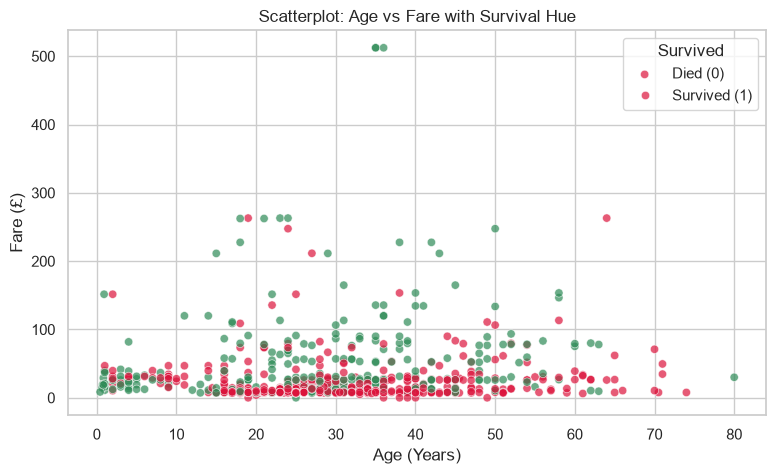

In [14]:
# Q16: Scatter with Hue
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='age', y='fare', hue='survived', palette={0: 'crimson', 1: 'seagreen'}, alpha=0.7)
plt.title("Scatterplot: Age vs Fare with Survival Hue")
plt.xlabel("Age (Years)")
plt.ylabel("Fare (£)")
plt.legend(title='Survived', labels=['Died (0)', 'Survived (1)'])
plt.show()


**Observation for Q16:**
* Upper fare zone (£100+) me green dots (survived) dominantly distributed hain.
* Lower band (< £30) me red dots (did not survive) ka cluster bohot dense hai, chahe age koi bhi ho.


### Q17. 3D Scatter Plot (Age × Fare × Survival)
* **Goal**: Matplotlib 3D ke sath simultaneously continuous aur binary outputs visualize karna.


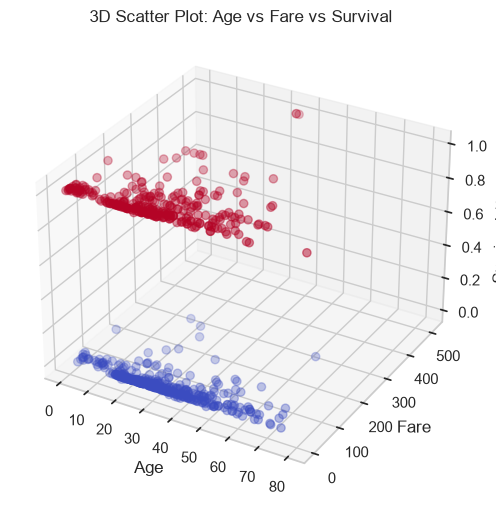

In [15]:
# Q17: 3D Scatter Plot
clean_3d = df[['age', 'fare', 'survived']].dropna()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(clean_3d['age'], clean_3d['fare'], clean_3d['survived'],
               c=clean_3d['survived'], cmap='coolwarm', s=35, alpha=0.7)

ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_zlabel('Survived (0 or 1)')
ax.set_title("3D Scatter Plot: Age vs Fare vs Survival")
plt.show()


**Observation for Q17:**
* $Z=0$ (non-survivor floor) par points mainly low-fare axis par congested hain.
* $Z=1$ (survivor floor) par points higher fare coordinates aur younger age values dono par spread hain.


### Q18. FacetGrid: Age vs Fare Across Passenger Classes
* **Goal**: Har class ke liye alag panel me distribution aur survival verify karna.


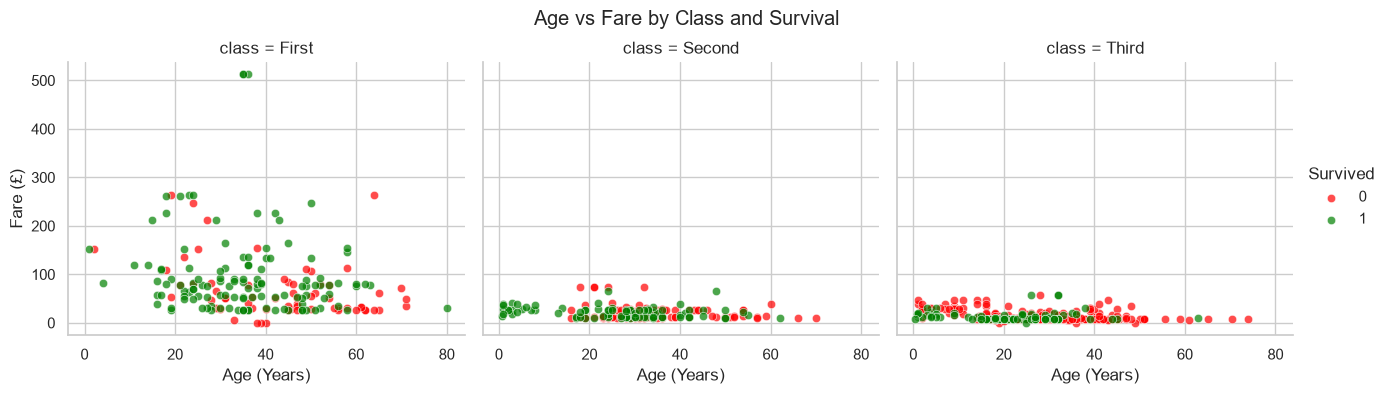

In [16]:
# Q18: FacetGrid
g = sns.FacetGrid(df, col='class', hue='survived', palette={0: 'red', 1: 'green'}, height=4, aspect=1.1)
g.map_dataframe(sns.scatterplot, x='age', y='fare', alpha=0.7)
g.add_legend(title='Survived')
g.set_axis_labels("Age (Years)", "Fare (£)")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Age vs Fare by Class and Survival")
plt.show()


**Observation for Q18:**
* **First Class**: Maximum fares aur green points (survivors) ka proportion sabse highest hai.
* **Third Class**: Fares bottom line par flat hain, aur red dots (casualties) overwhelmingly dominate karte hain.


### Q19. Jointplot: Joint & Marginal Distributions
* **Goal**: Marginal distribution histograms ke sath central bivariate pattern dekhna.


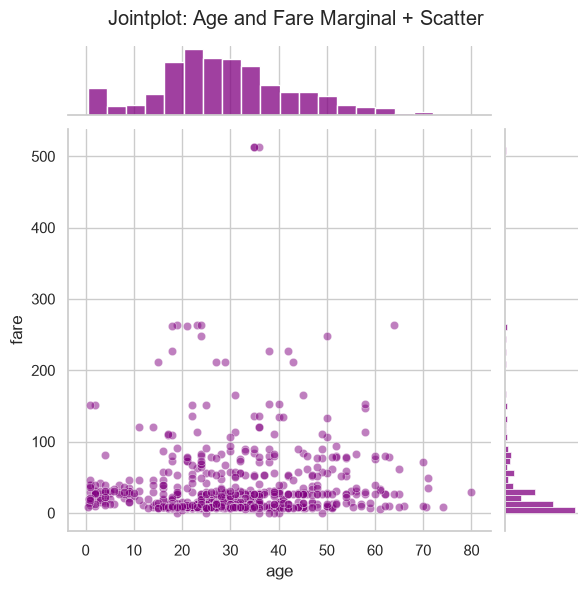

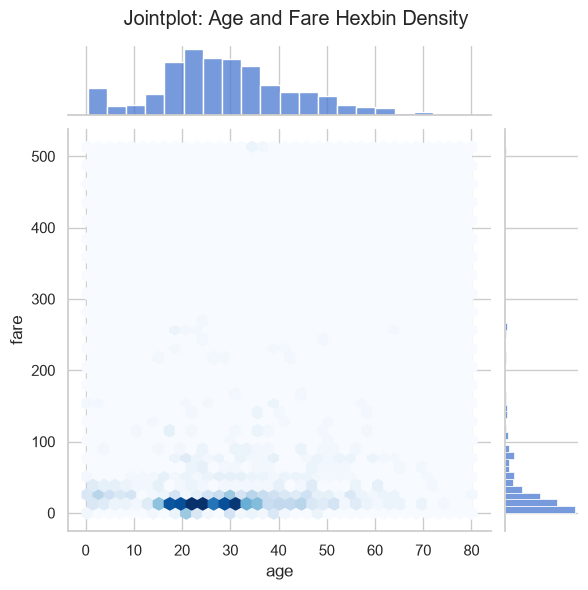

In [17]:
# Q19: Jointplot (Scatter & Hex)
# Scatter jointplot
sns.jointplot(data=df, x='age', y='fare', kind='scatter', height=6, color='purple', alpha=0.5)
plt.subplots_adjust(top=0.92)
plt.suptitle("Jointplot: Age and Fare Marginal + Scatter")
plt.show()

# Hexbin jointplot for density
sns.jointplot(data=df, x='age', y='fare', kind='hex', height=6, cmap='Blues')
plt.subplots_adjust(top=0.92)
plt.suptitle("Jointplot: Age and Fare Hexbin Density")
plt.show()


**Observation for Q19:**
* Marginal plots dikhate hain ki Age unimodal aur approximately normal hai, jabki Fare steep right-skewed peak banata hai.
* Hexbin plot highlight karta hai ki highest density Age 20-35 aur Fare < £20 ke intersection par hai.


### Q20. Pairplot: Numerical Variables Matrix
* **Goal**: Saare numerical features ke pairwise plots ek single grid me scan karna.


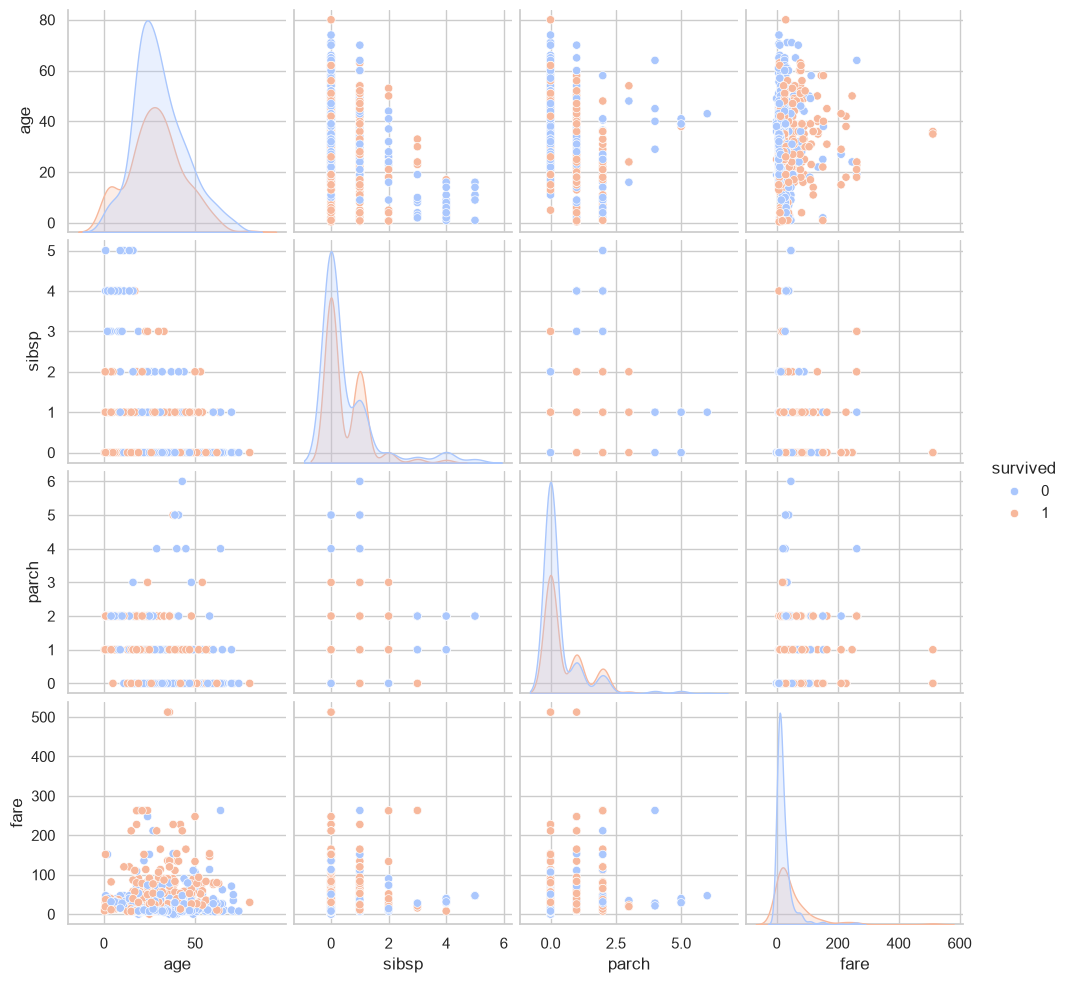

In [18]:
# Q20: Pairplot
pair_df = df[['survived', 'age', 'sibsp', 'parch', 'fare']].dropna()
sns.pairplot(pair_df, hue='survived', diag_kind='kde', palette='coolwarm')
plt.show()


**Observation for Q20:**
* Diagonal KDE plots clearly indicate karte hain ki `fare` survivor group me higher distribution shift dikhata hai.
* `sibsp` aur `parch` mainly discrete values hain jahan small family numbers survival me helpful dikhte hain.


### Q21. Bubble Plot (4 Dimensions simultaneously)
* **X**: Age | **Y**: Fare | **Size**: Family Size | **Hue**: Survival


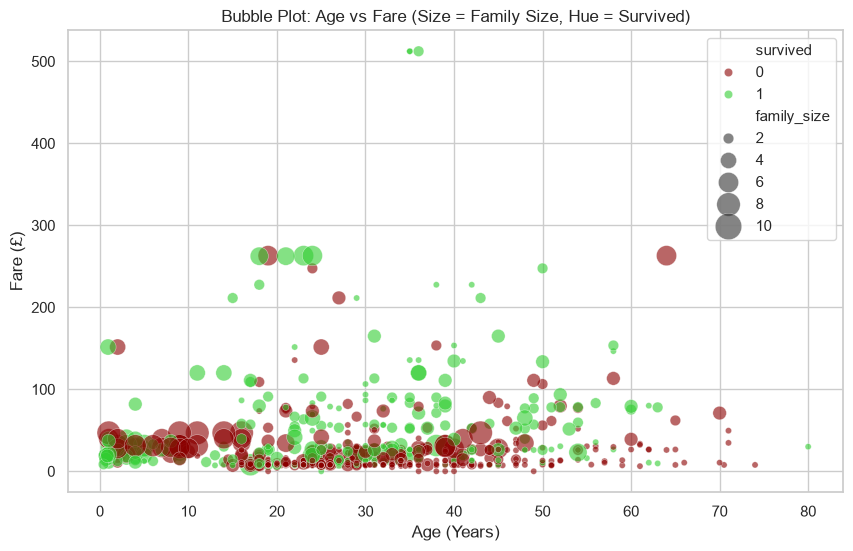

In [19]:
# Q21: Bubble Plot
df['family_size'] = df['sibsp'] + df['parch'] + 1

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='age',
    y='fare',
    size='family_size',
    sizes=(20, 400),
    hue='survived',
    palette={0: 'darkred', 1: 'limegreen'},
    alpha=0.6
)
plt.title("Bubble Plot: Age vs Fare (Size = Family Size, Hue = Survived)")
plt.xlabel("Age (Years)")
plt.ylabel("Fare (£)")
plt.show()


**Observation for Q21:**
* Single plot me four dimensions clearly interact karte hain.
* Very large bubbles (family size $\ge 5$) mostly lower-to-middle fare range me hain aur unka survival rate bohot low raha.


---
## SECTION Q & R — Categorical Breakdown & Survival Rates

### Q22, Q23, Q24: Passenger Counts by Sex, Class & Survival


C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\466775222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')
C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\466775222.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', ax=axes[1], palette='pastel')


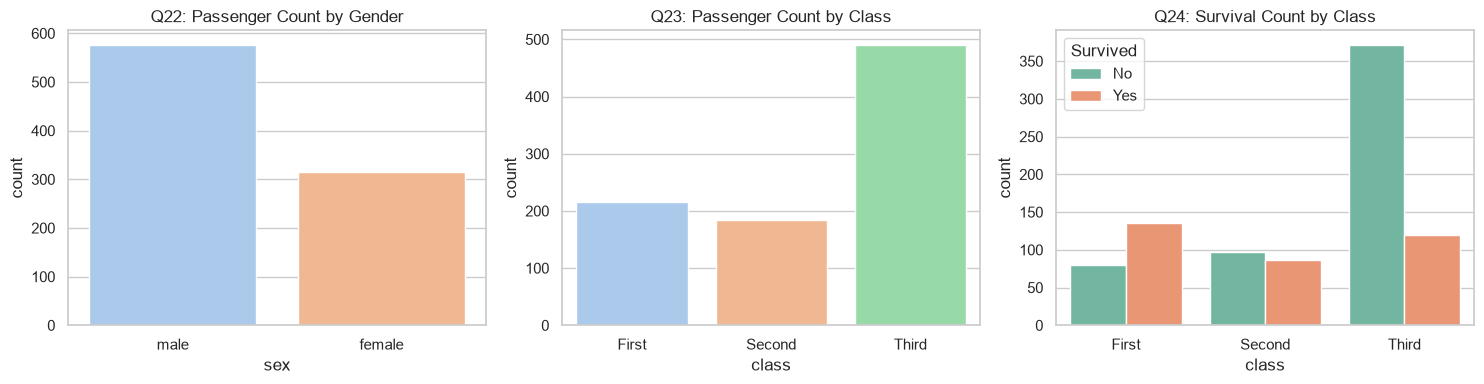

In [20]:
# Q22, Q23, Q24: Countplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel')
axes[0].set_title("Q22: Passenger Count by Gender")

sns.countplot(data=df, x='class', ax=axes[1], palette='pastel')
axes[1].set_title("Q23: Passenger Count by Class")

sns.countplot(data=df, x='class', hue='survived', ax=axes[2], palette='Set2')
axes[2].set_title("Q24: Survival Count by Class")
axes[2].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()


**Observation for Q22-Q24:**
* Male passengers (577) females (314) se lagbhag double the.
* Third class me sabse zyada passengers the (~491).
* Third class me deaths ka count survival se dramatically zyada tha.


### Q25, Q26, Q27: Survival Probabilities (Barplots)
* Note: Binary variable (`survived` 0/1) ka mean survival percentage / probability hota hai.


C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\2687889498.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='class', y='survived', ax=axes[0], ci=None, palette='Blues_d')
C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\2687889498.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='class', y='survived', ax=axes[0], ci=None, palette='Blues_d')
C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\2687889498.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[1], ci=None, palette='Reds_d')
C:\Users\Aman\AppData\Local\Temp\ipykernel_24568\2687889498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

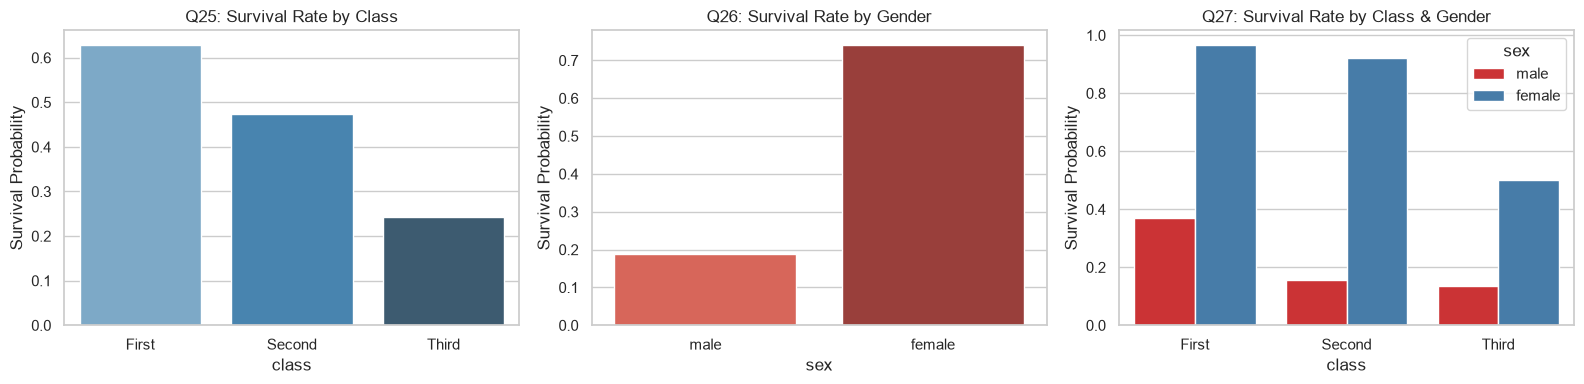

In [21]:
# Q25, Q26, Q27: Empirical Survival Rates
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=df, x='class', y='survived', ax=axes[0], ci=None, palette='Blues_d')
axes[0].set_title("Q25: Survival Rate by Class")
axes[0].set_ylabel("Survival Probability")

sns.barplot(data=df, x='sex', y='survived', ax=axes[1], ci=None, palette='Reds_d')
axes[1].set_title("Q26: Survival Rate by Gender")
axes[1].set_ylabel("Survival Probability")

sns.barplot(data=df, x='class', y='survived', hue='sex', ax=axes[2], ci=None, palette='Set1')
axes[2].set_title("Q27: Survival Rate by Class & Gender")
axes[2].set_ylabel("Survival Probability")

plt.tight_layout()
plt.show()


**Observation for Q25-Q27:**
* **By Class**: First Class survival rate ~63% tha, Second Class ~47%, aur Third Class sirf ~24%.
* **By Gender**: Female survival rate ~74% tha compared to males (~19%).
* **Interaction**: First aur Second Class ki female passengers ka survival rate >90% tha, jabki Third class males ka survival rate ~13% tha.


### Q28 & Q29: Continuous Variable Distribution & Skewness
* **Visualization**: Histogram with KDE.


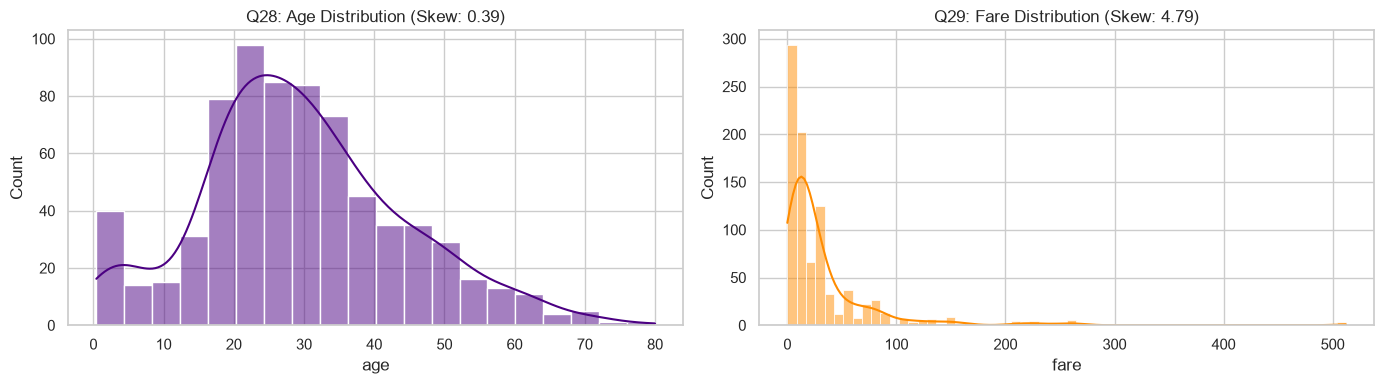

In [22]:
# Q28 & Q29: Histograms with KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='age', kde=True, ax=axes[0], color='indigo')
axes[0].set_title(f"Q28: Age Distribution (Skew: {df['age'].skew():.2f})")

sns.histplot(data=df, x='fare', kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f"Q29: Fare Distribution (Skew: {df['fare'].skew():.2f})")

plt.tight_layout()
plt.show()


**Observation for Q28 & Q29:**
* **Age Distribution**: Mild positive skewness (~0.39), roughly normal shape ke close hai with a peak around 20-30 years.
* **Fare Distribution**: Severe positive skewness (~4.79). Majority values 0 to 50 ke beech hain aur ek lambi right tail 500+ tak stretch hoti hai.


---
## Chapter 7: Project Conclusion & Synthesis
1. **Demographics**: Titanic par majority young males the jo Third Class me travel kar rahe the.
2. **Economic Disparity**: Fare distribution extremely right-skewed hai (IQR: £23.09, Max: £512.33). First class ticket holders ko superior physical access mila.
3. **Statistical Distinction**:
   * Covariance units aur scale se inflate ho jati hai ($Var(Fare) = 2469.4$).
   * Correlation scale-free standardize metric provide karta hai ($r(Fare, Survived) = +0.26$).
4. **Correlation ≠ Causation**: Higher fare ne directly survival cause nahi kiya; balki upper-class cabin location, deck proximity, aur evacuation protocol ne survival rate ko determine kiya.
5. **Key Survival Drivers**: Gender (Female: 74% vs Male: 19%) aur Passenger Class (1st: 63% vs 3rd: 24%) Titanic survival ke do primary driving factors the.
